<a href="https://colab.research.google.com/github/araffin/rl-tutorial-jnrr19/blob/sb3/5_custom_gym_env.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stable Baselines3 Tutorial - Creating a custom Gym environment

Github repo: https://github.com/araffin/rl-tutorial-jnrr19/tree/sb3/

Stable-Baselines3: https://github.com/DLR-RM/stable-baselines3

Documentation: https://stable-baselines3.readthedocs.io/en/master/

SB3-Contrib: https://github.com/Stable-Baselines-Team/stable-baselines3-contrib

RL Baselines3 zoo: https://github.com/DLR-RM/rl-baselines3-zoo


## Introduction

In this notebook, you will learn how to use your own environment following the OpenAI Gym interface.
Once it is done, you can easily use any compatible (depending on the action space) RL algorithm from Stable Baselines on that environment.

## Install Dependencies and Stable Baselines3 Using Pip



In [1]:
# for autoformatting
# %load_ext jupyter_black

In [2]:
# !pip install "stable-baselines3[extra]>=2.0.0a4"

## First steps with the gym interface

As you have noticed in the previous notebooks, an environment that follows the gym interface is quite simple to use.
It provides to this user mainly three methods, which have the following signature (for gym versions > 0.26)
- `reset()` called at the beginning of an episode, it returns an observation and a dictionary with additional info (defaults to an empty dict)
- `step(action)` called to take an action with the environment, it returns the next observation, the immediate reward, whether new state is a terminal state (episode is finished), whether the max number of timesteps is reached (episode is artificially finished), and additional information
- (Optional) `render()` which allow to visualize the agent in action. Note that graphical interface does not work on google colab, so we cannot use it directly (we have to rely on `render_mode='rbg_array'` to retrieve an image of the scene).

Under the hood, it also contains two useful properties:
- `observation_space` which one of the gym spaces (`Discrete`, `Box`, ...) and describe the type and shape of the observation
- `action_space` which is also a gym space object that describes the action space, so the type of action that can be taken

The best way to learn about [gym spaces](https://gymnasium.farama.org/api/spaces/) is to look at the [source code](https://github.com/Farama-Foundation/Gymnasium/tree/main/gymnasium/spaces), but you need to know at least the main ones:
- `gym.spaces.Box`: A (possibly unbounded) box in $R^n$. Specifically, a Box represents the Cartesian product of n closed intervals. Each interval has the form of one of [a, b], (-oo, b], [a, oo), or (-oo, oo). Example: A 1D-Vector or an image observation can be described with the Box space.
```python
# Example for using image as input:
observation_space = spaces.Box(low=0, high=255, shape=(HEIGHT, WIDTH, N_CHANNELS), dtype=np.uint8)
```                                       

- `gym.spaces.Discrete`: A discrete space in $\{ 0, 1, \dots, n-1 \}$
  Example: if you have two actions ("left" and "right") you can represent your action space using `Discrete(2)`, the first action will be 0 and the second 1.


[Documentation on custom env](https://stable-baselines3.readthedocs.io/en/master/guide/custom_env.html)

Also keep in mind that Stabe-baselines internally uses the previous gym API (<0.26), so every VecEnv returns only the observation after resetting and returns a 4-tuple instead of a 5-tuple  (terminated & truncated are already combined to done).

In [3]:
import gymnasium as gym

env = gym.make("CartPole-v1", render_mode="rgb_array")

# Box(4,) means that it is a Vector with 4 components
print("Observation space:", env.observation_space)
print("Shape:", env.observation_space.shape)
# Discrete(2) means that there is two discrete actions
print("Action space:", env.action_space)

# The reset method is called at the beginning of an episode
obs, info = env.reset()
# Sample a random action
action = env.action_space.sample()
print("Sampled action:", action)
obs, reward, terminated, truncated, info = env.step(action)
# Note the obs is a numpy array
# info is an empty dict for now but can contain any debugging info
# reward is a scalar
print(obs.shape, reward, terminated, truncated, info)

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Shape: (4,)
Action space: Discrete(2)
Sampled action: 1
(4,) 1.0 False False {}


<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.


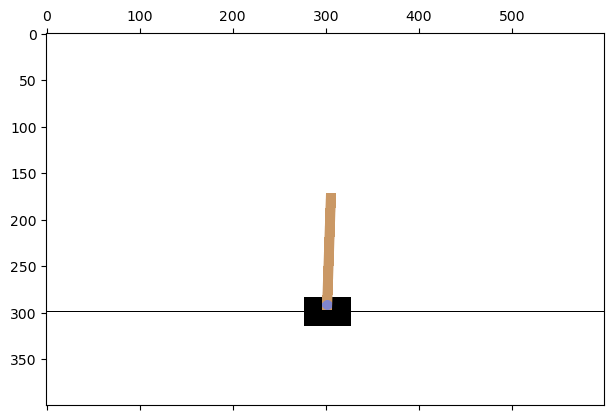

In [4]:
import matplotlib.pyplot as plt
env.reset()
rend = env.render()
plt.matshow(rend)

##  Gym env skeleton

In practice this is how a gym environment looks like.
Here, we have implemented a simple grid world were the agent must learn to go always left.

In [5]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces


class GoLeftEnv(gym.Env):
    """
    Custom Environment that follows gym interface.
    This is a simple env where the agent must learn to go always left.
    """

    # Because of google colab, we cannot implement the GUI ('human' render mode)
    metadata = {"render_modes": ["console"]}

    # Define constants for clearer code
    LEFT = 0
    RIGHT = 1

    def __init__(self, grid_size=10, render_mode="console"):
        super(GoLeftEnv, self).__init__()
        self.render_mode = render_mode

        # Size of the 1D-grid
        self.grid_size = grid_size
        # Initialize the agent at the right of the grid
        self.agent_pos = grid_size - 1

        # Define action and observation space
        # They must be gym.spaces objects
        # Example when using discrete actions, we have two: left and right
        n_actions = 2
        self.action_space = spaces.Discrete(n_actions)
        # The observation will be the coordinate of the agent
        # this can be described both by Discrete and Box space
        self.observation_space = spaces.Box(
            low=0, high=self.grid_size, shape=(1,), dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        """
        Important: the observation must be a numpy array
        :return: (np.array)
        """
        super().reset(seed=seed, options=options)
        # Initialize the agent at the right of the grid
        self.agent_pos = self.grid_size - 1
        # here we convert to float32 to make it more general (in case we want to use continuous actions)
        return np.array([self.agent_pos]).astype(np.float32), {}  # empty info dict

    def step(self, action):
        if action == self.LEFT:
            self.agent_pos -= 1
        elif action == self.RIGHT:
            self.agent_pos += 1
        else:
            raise ValueError(
                f"Received invalid action={action} which is not part of the action space"
            )

        # Account for the boundaries of the grid
        self.agent_pos = np.clip(self.agent_pos, 0, self.grid_size)

        # Are we at the left of the grid?
        terminated = bool(self.agent_pos == 0)
        truncated = False  # we do not limit the number of steps here

        # Null reward everywhere except when reaching the goal (left of the grid)
        reward = 1 if self.agent_pos == 0 else 0

        # Optionally we can pass additional info, we are not using that for now
        info = {}

        return (
            np.array([self.agent_pos]).astype(np.float32),
            reward,
            terminated,
            truncated,
            info,
        )

    def render(self):
        # agent is represented as a cross, rest as a dot
        if self.render_mode == "console":
            print("." * self.agent_pos, end="")
            print("x", end="")
            print("." * (self.grid_size - self.agent_pos))

    def close(self):
        pass

### Validate the environment

Stable Baselines3 provides a [helper](https://stable-baselines3.readthedocs.io/en/master/common/env_checker.html) to check that your environment follows the Gym interface. It also optionally checks that the environment is compatible with Stable-Baselines (and emits warning if necessary).

In [6]:
from stable_baselines3.common.env_checker import check_env

In [7]:
env = GoLeftEnv()
# If the environment don't follow the interface, an error will be thrown
check_env(env, warn=True)

### Testing the environment

In [8]:
env = GoLeftEnv(grid_size=10)

obs, _ = env.reset()
env.render()

print(env.observation_space)
print(env.action_space)
print(env.action_space.sample())

GO_LEFT = 0
# Hardcoded best agent: always go left!
n_steps = 20
for step in range(n_steps):
    print(f"Step {step + 1}")
    obs, reward, terminated, truncated, info = env.step(GO_LEFT)
    done = terminated or truncated
    print("obs=", obs, "reward=", reward, "done=", done)
    env.render()
    if done:
        print("Goal reached!", "reward=", reward)
        break

.........x.
Box(0.0, 10.0, (1,), float32)
Discrete(2)
0
Step 1
obs= [8.] reward= 0 done= False
........x..
Step 2
obs= [7.] reward= 0 done= False
.......x...
Step 3
obs= [6.] reward= 0 done= False
......x....
Step 4
obs= [5.] reward= 0 done= False
.....x.....
Step 5
obs= [4.] reward= 0 done= False
....x......
Step 6
obs= [3.] reward= 0 done= False
...x.......
Step 7
obs= [2.] reward= 0 done= False
..x........
Step 8
obs= [1.] reward= 0 done= False
.x.........
Step 9
obs= [0.] reward= 1 done= True
x..........
Goal reached! reward= 1


### Try it with Stable-Baselines

Once your environment follow the gym interface, it is quite easy to plug in any algorithm from stable-baselines

In [24]:
from stable_baselines3 import PPO, A2C, DQN
from stable_baselines3.common.env_util import make_vec_env

# Instantiate the env
vec_env = make_vec_env(GoLeftEnv, n_envs=1, env_kwargs=dict(grid_size=10))

In [25]:
# Train the agent
model = A2C("MlpPolicy", vec_env, verbose=0, device='cpu').learn(5000)

In [11]:
# Test the trained agent
# using the vecenv
obs = vec_env.reset()
n_steps = 20
for step in range(n_steps):
    action, _ = model.predict(obs, deterministic=True)
    print(f"Step {step + 1}")
    print("Action: ", action)
    obs, reward, done, info = vec_env.step(action)
    print("obs=", obs, "reward=", reward, "done=", done)
    vec_env.render()
    if done:
        # Note that the VecEnv resets automatically
        # when a done signal is encountered
        print("Goal reached!", "reward=", reward)
        break

Step 1
Action:  [0]
obs= [[8.]] reward= [0.] done= [False]
........x..
Step 2
Action:  [0]
obs= [[7.]] reward= [0.] done= [False]
.......x...
Step 3
Action:  [0]
obs= [[6.]] reward= [0.] done= [False]
......x....
Step 4
Action:  [0]
obs= [[5.]] reward= [0.] done= [False]
.....x.....
Step 5
Action:  [0]
obs= [[4.]] reward= [0.] done= [False]
....x......
Step 6
Action:  [0]
obs= [[3.]] reward= [0.] done= [False]
...x.......
Step 7
Action:  [0]
obs= [[2.]] reward= [0.] done= [False]
..x........
Step 8
Action:  [0]
obs= [[1.]] reward= [0.] done= [False]
.x.........
Step 9
Action:  [0]
obs= [[9.]] reward= [1.] done= [ True]
.........x.
Goal reached! reward= [1.]


## It is your turn now, be creative!

As an exercise, that's now your turn to build a custom gym environment.
There is no constrain about what to do, be creative! (but not too creative, there is not enough time for that)

If you don't have any idea, here is is a list of the environment you can implement:
- Transform the discrete grid world to a continuous one, you will need to change a bit the logic and the action space
- Create a 2D grid world and add walls
- Create a tic-tac-toe game


In [12]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg


class InertialContinuousArena(gym.Env):
    """
    Custom Environment that follows gym interface.
    This is an environment where the agent has impulsive control and 
    must learn to enter a 1x1 box at the origin.
    """

    metadata = {"render_modes": ["console",'rgb_array']}

    # Define constants for clearer code
    UP = 0
    DOWN = 1
    RIGHT = 2
    LEFT = 3
    COAST = 4

    action_list = [np.array([0,1]),  # UP
                   -np.array([0,1]), # DOWN
                   np.array([1,0]),  # RIGHT
                   -np.array([1,0]), # LEFT
                   np.array([0,0])]  # COAST

    GOAL = spaces.Box(np.array([-1,-1]),
                      np.array([1,1]),
                      shape=(2,),
                      dtype=np.float64) # GOAL is a 1x1 box around the origin. position only, ignores velocity!

    def __init__(self, arena_size=10, sample_rate=10, render_mode="rgb_array"):
        '''
        initializes a arena_size X arena_size square area
        '''
        super(InertialContinuousArena, self).__init__()
        self.render_mode = render_mode

        # Size of the 2D arena
        self.arena_size = arena_size

        # Sampling rate in Hz
        self.sample_rate=sample_rate
        
        # Initialize the agent near the lower-left
        self.agent_pos = [-arena_size*.9, -arena_size*.9]
        self.agent_vel = [0,0]

        # Define action and observation space
        # They must be gym.spaces objects
        # Example when using discrete actions, we have 5: thrust {up, down, left, right}, coast
        n_actions = 5
        self.action_space = spaces.Discrete(n_actions)
        # The observation will be [x_pos, y_pos, x_vel, y_vel] of the agent
        low = np.array([-arena_size, -arena_size, -np.inf, -np.inf])
        high = np.array([arena_size, arena_size, np.inf, np.inf])
        self.observation_space = spaces.Box(
            low=low, high=high, shape=(4,), dtype=np.float64
        )

    def reset(self, seed=None, options=None):
        """
        Important: the observation must be a numpy array
        :return: (np.array)
        """
        super().reset(seed=seed, options=options)
        # Initialize the agent near the lower-left
        self.agent_pos = np.array([-self.arena_size*.9, -self.arena_size*.9])
        self.agent_vel = np.array([0,0])
        # here we convert to float32 to make it more general (in case we want to use continuous actions) NOT SURE IF THIS IS NECESSARY!!
        return np.concatenate((self.agent_pos,self.agent_vel)), {}  # empty info dict

    def step(self, action):
        if action not in [0,1,2,3,4] :
            raise ValueError(
                f"Received invalid action={action} which is not part of the action space"
            )
        
        self.agent_vel += self.action_list[action] # add an impulse taken from the action_list
        self.agent_pos += self.agent_vel/self.sample_rate # propagate the position at the given sampling rate

        # Account for the boundaries of the grid: 0 agent's velocity in the component where it hit the wall?
        for dim in range(2) :
            if self.agent_pos[dim] > self.arena_size :
                self.agent_pos[dim] = self.arena_size
                self.agent_vel[dim] = 0 # if we hit the x (y) boundary, zero-out the x (y) velocity
            elif self.agent_pos[dim] < -self.arena_size :
                self.agent_pos[dim] = -self.arena_size
                self.agent_vel[dim] = 0 # if we hit the x (y) boundary, zero-out the x (y) velocity
                
        # self.agent_pos = np.clip(self.agent_pos, [-self.arena_size,-self.arena_size], [self.arena_size,self.arena_size])

        # Are we at the center of the grid?
        terminated = self.GOAL.contains(self.agent_pos)
        truncated = False  # we do not limit the number of steps here

        # Null reward everywhere except when reaching the goal (left of the grid)
        reward = 0
        if action != self.COAST :
            reward -= 1 # thrust is costly
        if terminated :
            reward += 10 # getting to the goal is good
        else:
            reward -= 1/self.sample_rate # penalize delay (lose 1 reward per simulation second)

        # Optionally we can pass additional info, we are not using that for now
        info = {}

        return (
            np.concatenate((self.agent_pos,self.agent_vel)),#.astype(np.float32),
            reward,
            terminated,
            truncated,
            info,
        )

    def render(self):
        # agent is represented as a cross, rest as a dot
        if self.render_mode == "console":
            print("." * self.agent_pos, end="")
            print("x", end="")
            print("." * (self.grid_size - self.agent_pos))

        if self.render_mode == "rgb_array":
    
            # Unpack state
            pos = self.agent_pos
            vel = self.agent_vel
            vel_mag = np.linalg.norm(self.agent_vel)
        
            # Create a figure and manually set the canvas
            fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
            canvas = FigureCanvasAgg(fig)  # explicitly use Agg canvas
            fig.set_canvas(canvas)
        
            ax.set_xlim(-self.arena_size, self.arena_size)
            ax.set_ylim(-self.arena_size, self.arena_size)
            ax.set_aspect('equal')
            ax.axis("off")

            ax.plot(pos[0], pos[1], 'ro', markersize=5)
        
            # Draw the agent as an arrow (if vel is nonzero)
            if vel_mag > 1e-6:
                ax.arrow(
                    pos[0], pos[1],
                    vel[0], vel[1],
                    head_width=0.5,
                    head_length=0.7,
                    fc='blue',
                    ec='blue',
                    length_includes_head=True
                )
            
            # Draw arena border
            ax.plot([-self.arena_size, self.arena_size, self.arena_size, -self.arena_size, -self.arena_size],
                    [-self.arena_size, -self.arena_size, self.arena_size, self.arena_size, -self.arena_size], 'k-', linewidth=1)
        
            # Render to RGB array
            canvas.draw()
            buf = canvas.buffer_rgba()  # use RGBA buffer
            width, height = fig.get_size_inches() * fig.dpi
            image = np.frombuffer(buf, dtype=np.uint8).reshape(int(height), int(width), 4)[..., :3]  # strip alpha
        
            plt.close(fig)
            return image


    def close(self):
        pass

env = InertialContinuousArena()

In [13]:
check_env(env)
env.reset()

(array([-9., -9.,  0.,  0.]), {})

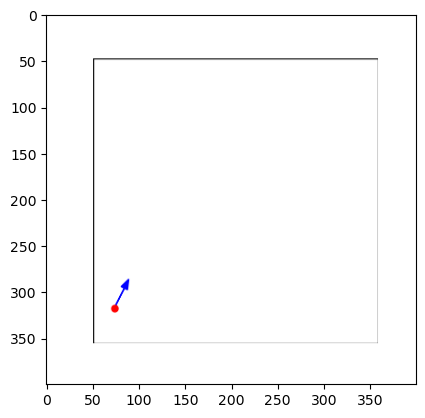

In [20]:
env.step(env.action_space.sample())
img = env.render()
plt.imshow(img)

In [34]:
from stable_baselines3 import PPO, A2C, DQN
from stable_baselines3.common.env_util import make_vec_env

# Instantiate the env
vec_env = make_vec_env(InertialContinuousArena, n_envs=1, env_kwargs=dict(arena_size=10))

In [35]:
vec_env.reset()

array([[-9., -9.,  0.,  0.]])

In [46]:
# Train the agent
model = A2C("MlpPolicy", vec_env, verbose=0, device='cpu').learn(5000)

(1, 4)

In [48]:
model.predict(obs)

(array([4], dtype=int64), None)

In [11]:
# Test the trained agent
# using the vecenv
obs = vec_env.reset()
n_steps = 20
for step in range(n_steps):
    action, _ = model.predict(obs, deterministic=True)
    print(f"Step {step + 1}")
    print("Action: ", action)
    obs, reward, done, info = vec_env.step(action)
    print("obs=", obs, "reward=", reward, "done=", done)
    vec_env.render()
    if done:
        # Note that the VecEnv resets automatically
        # when a done signal is encountered
        print("Goal reached!", "reward=", reward)
        break

Step 1
Action:  [0]
obs= [[8.]] reward= [0.] done= [False]
........x..
Step 2
Action:  [0]
obs= [[7.]] reward= [0.] done= [False]
.......x...
Step 3
Action:  [0]
obs= [[6.]] reward= [0.] done= [False]
......x....
Step 4
Action:  [0]
obs= [[5.]] reward= [0.] done= [False]
.....x.....
Step 5
Action:  [0]
obs= [[4.]] reward= [0.] done= [False]
....x......
Step 6
Action:  [0]
obs= [[3.]] reward= [0.] done= [False]
...x.......
Step 7
Action:  [0]
obs= [[2.]] reward= [0.] done= [False]
..x........
Step 8
Action:  [0]
obs= [[1.]] reward= [0.] done= [False]
.x.........
Step 9
Action:  [0]
obs= [[9.]] reward= [1.] done= [ True]
.........x.
Goal reached! reward= [1.]
